# iEMG vs sEMG

Using the sEMG -> we test the performance

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys

sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
from github.Share import shared_iENG_sENG

import warnings
warnings.filterwarnings('ignore')

In [3]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'

### 방금 Manual하게 feature extraction 을 써봤는데 그냥 원래 저장되어 있는 mat['Data_Fea'] 보다 한참 안좋음 - 코드에 문제 있는듯

(34567, 4, 14, 1) (34567,)
(8661, 4, 14, 1) (8661,)
Start Training (total epochs: 100)...
Maximum training accuracy : 78.9%
Maximum validation accuracy : 70.86%


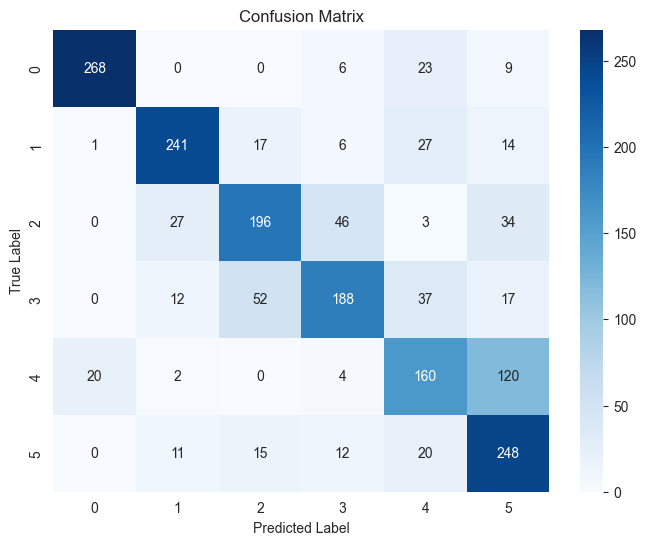

In [4]:
H = []

H_CM = shared_iENG_sENG.run(subject='Minjeong', Train_session=[0, 1, 2, 3], Test_session=[4])
H.append(H_CM)

(34584, 4, 14, 1) (34584,)
(8644, 4, 14, 1) (8644,)
Start Training (total epochs: 100)...
Maximum training accuracy : 80.14%
Maximum validation accuracy : 80.17%


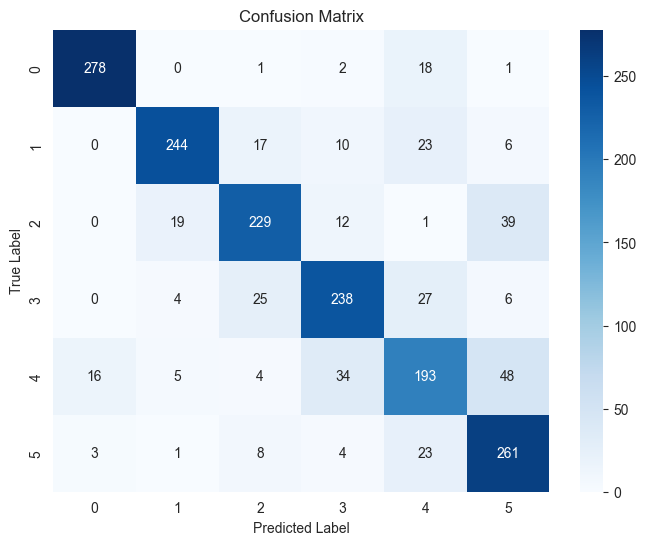

In [5]:
H_CM = shared_iENG_sENG.run(subject='Minjeong', Train_session=[0, 1, 2, 4], Test_session=[3])
H.append(H_CM)

(34588, 4, 14, 1) (34588,)
(8640, 4, 14, 1) (8640,)
Start Training (total epochs: 100)...
Maximum training accuracy : 77.97%
Maximum validation accuracy : 82.34%


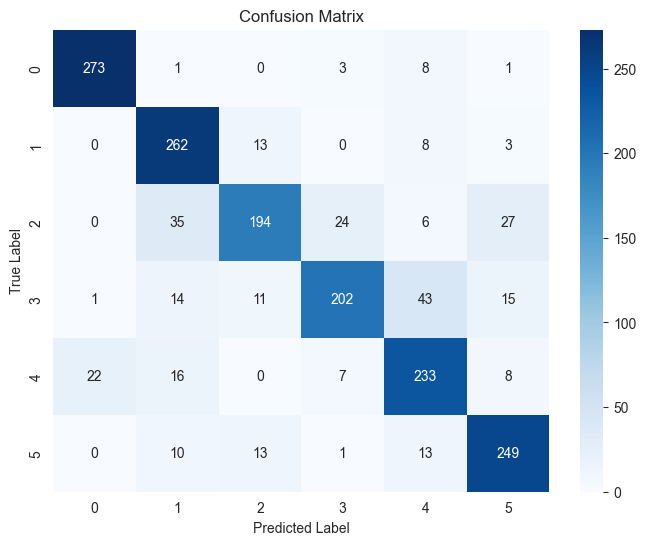

In [6]:
H_CM = shared_iENG_sENG.run(subject='Minjeong', Train_session=[0, 1, 3, 4], Test_session=[2])
H.append(H_CM)

(34580, 4, 14, 1) (34580,)
(8648, 4, 14, 1) (8648,)
Start Training (total epochs: 100)...
Maximum training accuracy : 77.2%
Maximum validation accuracy : 80.68%


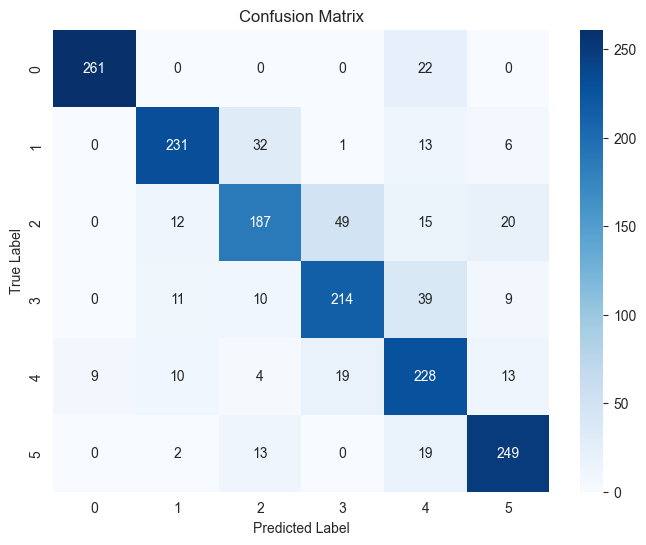

In [7]:
H_CM = shared_iENG_sENG.run(subject='Minjeong', Train_session=[0, 2, 3, 4], Test_session=[1])
H.append(H_CM)

(34593, 4, 14, 1) (34593,)
(8635, 4, 14, 1) (8635,)
Start Training (total epochs: 100)...
Maximum training accuracy : 79.33%
Maximum validation accuracy : 79.1%


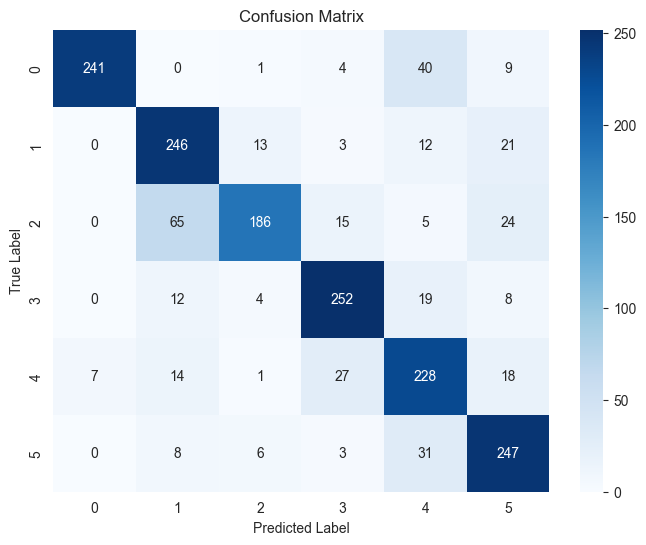

In [8]:
H_CM = shared_iENG_sENG.run(subject='Minjeong', Train_session=[1, 2, 3, 4], Test_session=[0])
H.append(H_CM)

In [9]:
np.mean(H, axis=0)

array([[2.642e+02, 2.000e-01, 4.000e-01, 3.000e+00, 2.220e+01, 4.000e+00],
       [2.000e-01, 2.448e+02, 1.840e+01, 4.000e+00, 1.660e+01, 1.000e+01],
       [0.000e+00, 3.160e+01, 1.984e+02, 2.920e+01, 6.000e+00, 2.880e+01],
       [2.000e-01, 1.060e+01, 2.040e+01, 2.188e+02, 3.300e+01, 1.100e+01],
       [1.480e+01, 9.400e+00, 1.800e+00, 1.820e+01, 2.084e+02, 4.140e+01],
       [6.000e-01, 6.400e+00, 1.100e+01, 4.000e+00, 2.120e+01, 2.508e+02]])

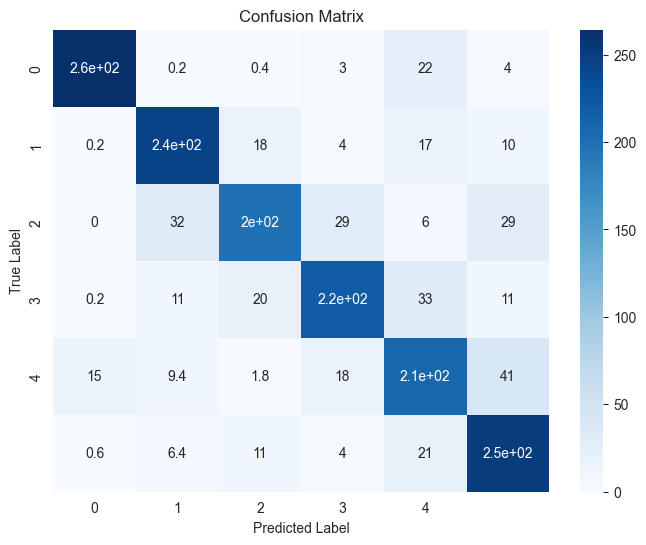

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.mean(H, axis=0), annot=True, cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [11]:
pd.DataFrame(np.mean(H, axis=0)).to_csv('results/subject_MJ_cross_validation_result_sENG-6class.csv', index=False)

# Conclusion

sENG - 성능 잘나옴: 2D CNN 썼을때 (모든 feature 사용시) 약 77~91% in intersession

내일 병찬이랑 민정이 데이터 collection해서 실험돌리기

# Analysis - gesture 별로만 비교 해야할듯
- collection 부위도 다르고 amputee라서 애매함
- 근데 제스쳐 자체는 같았으니 feature로 해도될듯